# Customer Churn Prediction

Predicting which Telco customers are likely to cancel their subscription, using the IBM Telco Customer Churn dataset (7,043 customers, 21 features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data cleaning

`TotalCharges` is stored as an object column instead of numeric — a quick look shows some rows have blank strings instead of a number. These all turn out to be customers with `tenure == 0`, i.e. brand new customers who haven't been billed yet.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [6]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])

## Exploratory data analysis

In [8]:
churn_rate = df["Churn"].value_counts(normalize=True)
churn_rate

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

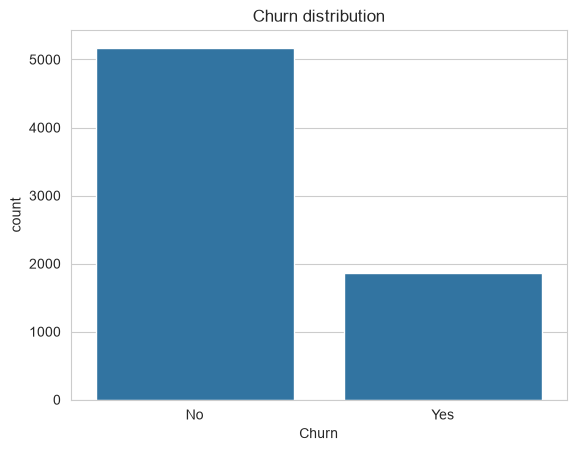

In [9]:
sns.countplot(data=df, x="Churn")
plt.title("Churn distribution")
plt.savefig("../results/churn_distribution.png", bbox_inches="tight")
plt.show()

About 27% of customers churned. That's an imbalanced target, which matters later — a model that just predicts "No" every time would already be 73% accurate without being useful, so accuracy alone won't tell us much.

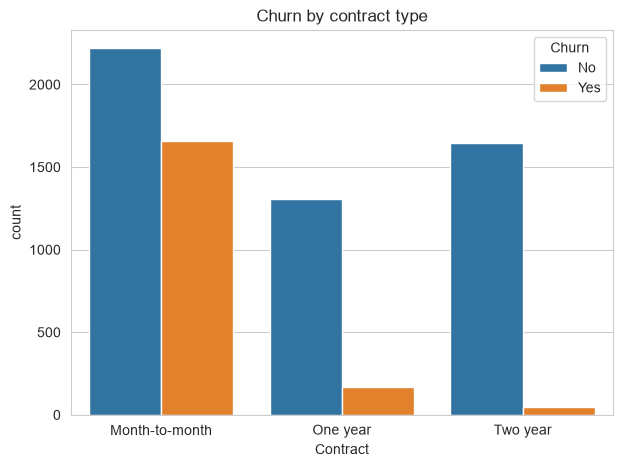

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by contract type")
plt.savefig("../results/churn_by_contract.png", bbox_inches="tight")
plt.show()

Month-to-month customers churn far more than customers on one or two year contracts. That makes intuitive sense — there's no penalty for leaving, so contract type looks like it'll be one of the strongest predictors.

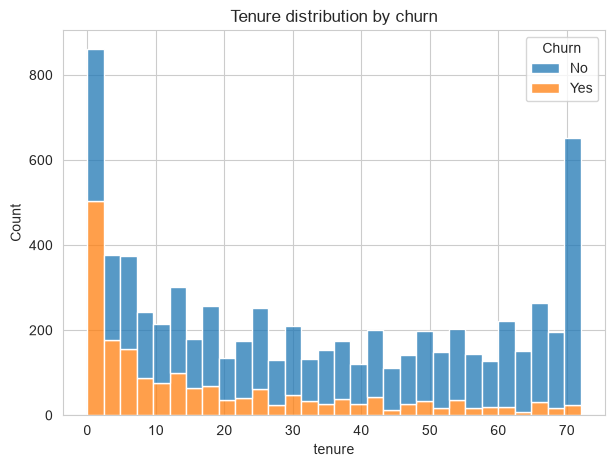

In [11]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure distribution by churn")
plt.savefig("../results/tenure_by_churn.png", bbox_inches="tight")
plt.show()

Churn is heavily concentrated in the first few months. Customers who stick around past year one are much less likely to leave.

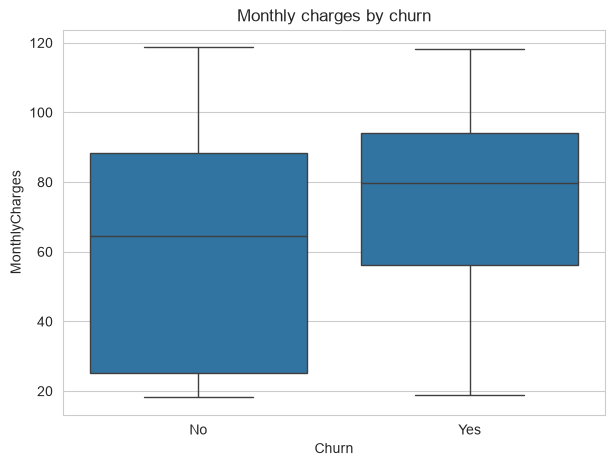

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges by churn")
plt.savefig("../results/charges_by_churn.png", bbox_inches="tight")
plt.show()

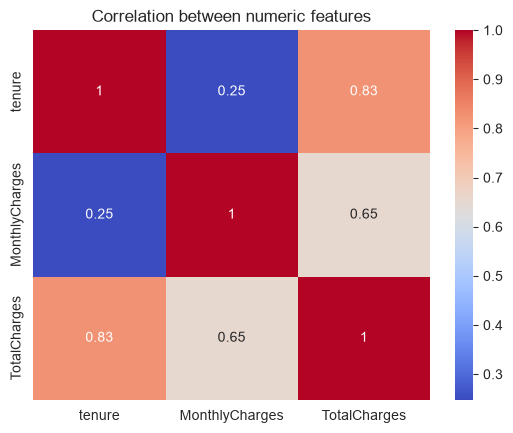

In [13]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.savefig("../results/correlation_heatmap.png", bbox_inches="tight")
plt.show()

`TotalCharges` is basically `tenure * MonthlyCharges`, so it's highly correlated with tenure. Worth keeping in mind for feature engineering — it's not adding much independent information.

## Feature engineering

Most columns are categorical text (`Yes`/`No`, service types, contract type, etc.), so they need to be converted to numbers before a model can use them. Binary columns (`Yes`/`No`, `Male`/`Female`) get label encoded; columns with more than two categories get one-hot encoded so the model doesn't assume a false order between them.

In [14]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

df.shape

(7043, 31)

## Train/test split and scaling

In [15]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

## Baseline model: Logistic Regression

Starting with Logistic Regression because it's simple, fast, and gives a baseline to compare more complex models against. If a more complicated model can't beat this, it's not worth the extra complexity.

Logistic Regression is sensitive to feature scale — `tenure`, `MonthlyCharges` and `TotalCharges` range into the thousands while the one-hot columns are just 0/1, which stops the solver from converging cleanly. Scaling the numeric columns fixes that.

In [16]:
scaler = StandardScaler()
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

    No churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421710713270816


## Random Forest

Trying a Random Forest next to see if capturing non-linear relationships and feature interactions improves on the linear baseline.

In [18]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8408160892815624


## Comparing the two models

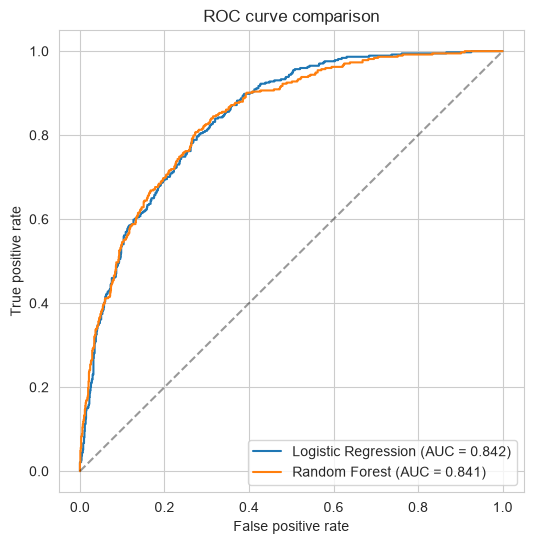

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve comparison")
plt.legend()
plt.savefig("../results/roc_comparison.png", bbox_inches="tight")
plt.show()

Logistic Regression and Random Forest come out very close on ROC-AUC. For a dataset like this, where most features are already fairly linearly related to churn (contract type, tenure), Random Forest's ability to model non-linear interactions doesn't add much. Logistic Regression is also more interpretable, so it's a reasonable choice to go with in practice.

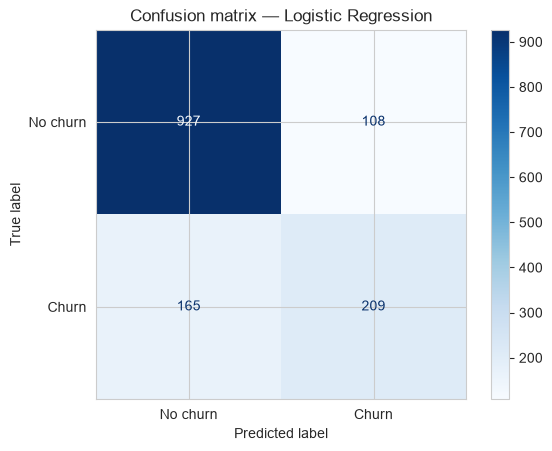

In [20]:
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(cmap="Blues")
plt.title("Confusion matrix — Logistic Regression")
plt.savefig("../results/confusion_matrix.png", bbox_inches="tight")
plt.show()

## Feature importance

Using the Random Forest's built-in feature importances to see which factors matter most for churn — useful for a business audience even if Logistic Regression ends up being the model of choice.

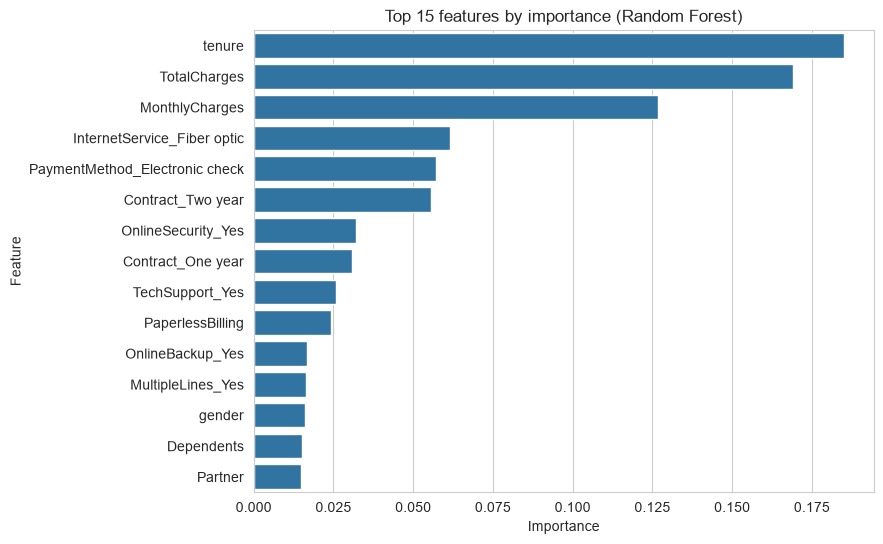

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 features by importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("../results/feature_importance.png", bbox_inches="tight")
plt.show()

Tenure, monthly charges, total charges, and contract type dominate — consistent with what the EDA already suggested. Customers on month-to-month contracts with high monthly charges and low tenure are the highest-risk group.

## Improving recall

The baseline Logistic Regression only catches 56% of actual churners. For a retention campaign, missing that many at-risk customers is a bigger problem than a few wasted offers to customers who wouldn't have churned — so it's worth trying to push recall up, even at some cost to precision.

Two changes, in order of effort:

1. **`class_weight="balanced"`** — tells the model to penalize mistakes on the minority class (churn) more heavily during training, instead of treating both classes as equally important.
2. **Lowering the decision threshold** — by default, `predict()` calls anything above 50% probability "churn." Lowering that bar catches more real churners, at the cost of more false alarms.

In [22]:
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_bal.fit(X_train_scaled, y_train)

y_pred_bal = log_reg_bal.predict(X_test_scaled)
y_proba_bal = log_reg_bal.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_bal, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8417318969748638


Just balancing the class weights already moves recall a lot — worth checking, since ROC-AUC barely changes. That makes sense: ROC-AUC measures how well the model *ranks* churners above non-churners across every possible threshold, and class weighting doesn't change the ranking, just where the model's default 50% cutoff falls relative to it.

Next, tuning the threshold directly on the *original* (non-balanced) model's probabilities, to see the full trade-off between precision and recall as the cutoff moves.

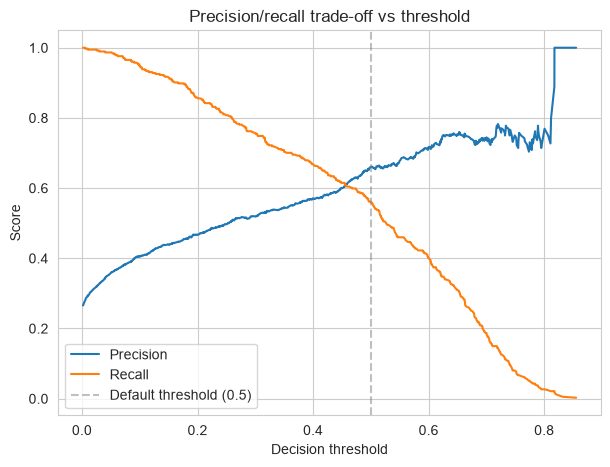

In [23]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision/recall trade-off vs threshold")
plt.legend()
plt.savefig("../results/threshold_tuning.png", bbox_inches="tight")
plt.show()

In [24]:
threshold = 0.3
y_pred_thresh = (y_proba_lr >= threshold).astype(int)

print(classification_report(y_test, y_pred_thresh, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.89      0.75      0.81      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



Dropping the threshold to 0.3 lands recall at 0.76 — actually slightly *below* what class weighting achieved (0.78), and with a bit less precision too. So for this dataset, `class_weight="balanced"` turns out to be the more effective of the two techniques, not just the simpler one. Threshold tuning is still a useful lever in general (it lets you dial recall up or down continuously to match a specific business cost trade-off), but here it doesn't beat class weighting outright.

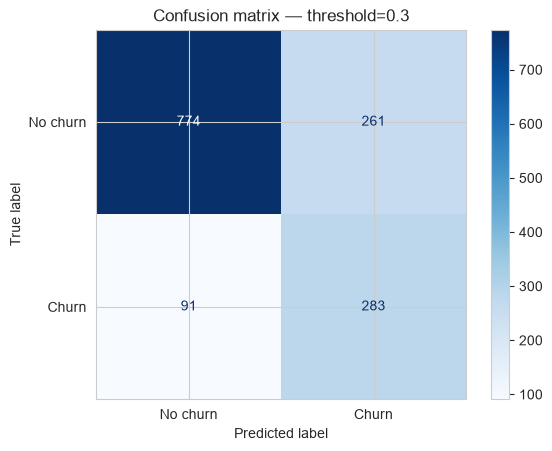

In [25]:
cm_thresh = confusion_matrix(y_test, y_pred_thresh)
ConfusionMatrixDisplay(cm_thresh, display_labels=["No churn", "Churn"]).plot(cmap="Blues")
plt.title(f"Confusion matrix — threshold={threshold}")
plt.savefig("../results/confusion_matrix_tuned.png", bbox_inches="tight")
plt.show()

## Conclusion

The baseline Logistic Regression and Random Forest land around 0.84 ROC-AUC, with recall on the churn class around 0.53-0.56 at the default 0.5 threshold — the models catch roughly half of churners out of the box.

Two simple changes were tried:
- **Class weighting** raises churn recall from 0.56 to **0.78**, with precision dropping from 0.66 to 0.50, and barely changes ROC-AUC (0.842 → 0.842) — it doesn't make the model "better" in any absolute sense, it just moves the default cutoff to a more useful spot for this problem.
- **Threshold tuning** (dropping to 0.3) reaches recall of 0.76, precision 0.52 — comparable to class weighting but not better. It's still a useful lever in principle (it can be tuned continuously to any point on the trade-off curve), but for this dataset class weighting achieved a better result with less manual tuning.

Given that missing a churner is normally costlier to a business than a wasted discount, the class-weighted Logistic Regression is the recommended model: recall of 0.78 versus the original 0.56, for a real but reasonable cost in precision.

The strongest churn signals throughout are contract type, tenure, and monthly charges. In practice, this points to a fairly simple retention strategy: offer incentives to switch month-to-month customers onto longer contracts, and pay closer attention to customers in their first few months.